# Fast convolution

So, the english is not very good, I will improve that

In [3]:
import itertools

import sympy as sy
import numpy as np
import scipy as sc

In [4]:
import fitz

In [5]:
from sympy import init_printing
init_printing(use_latex='png', forecolor='White', backcolor='Black')

In [6]:
from fast_convolution import toom_cook, g2bg, recursive_log2, log2_lst, log2_matrix

In [7]:
from utils import plot_pdf

In [8]:
doc = fitz.open('Blahut_2010_Fast algorithms for signal processing.pdf')

Size of vectors

In [9]:
d_num = 4
g_num = 3

Example of vectors for the convolution

In [10]:
d_values = list(range(1, d_num+1))
g_values = list(range(1, g_num+1))
print(d_values, g_values)

[1, 2, 3, 4] [1, 2, 3]


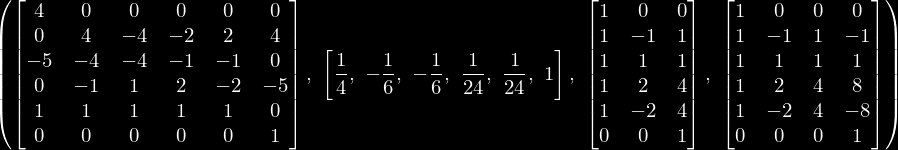

In [11]:
c_mtx, cq, b_mtx, a_mtx = toom_cook(d_num, g_num, [0, -1, 1, 2, -2, np.inf])
c_mtx, cq, b_mtx, a_mtx

In [12]:
# def recursive_log2(n):
#     def _recursive_log2(n):
#         return  [e for e, b in enumerate(bin(n)[2::][::-1]) if b == '1']

#     sign = -1 if n < 0 else 1
#     if n > 0:
#         base_sig = 1
#     elif n < 0:
#         base_sig = -1
#     else:
#         # n == 0:
#         return {}

#     if isinstance(n, sy.Integer):
#         exp_z =  _recursive_log2(n)
#         out = {
#             "s": sign,
#             "z": exp_z,
#         }
#     else:
#         exp_p =  _recursive_log2(n.p)
#         exp_q =  _recursive_log2(n.q)
#         out = {
#             "s": sign,
#             "p": exp_p,
#             "q": exp_q,
#         }
#     return out


In [13]:
# lst_in = c_mtx.tolist()
# lst_out = [[None for c in range(len(lst_in[0]))] for r in range(len(lst_in))]
# for r, row in enumerate(lst_in):
#     for c, col in enumerate(row):
#         lst_out[r][c] = recursive_log2(col)
# lst_out

In [14]:
# s = c_lst2[0][0]["s"]
# z = c_lst2[0][0]["z"]
# # q = c_lst2[0][0]["q"]
# s, z
# s*(2**z[0])

In [15]:
# c_mtx3 = sy.zeros(c_mtx.shape[0], c_mtx.shape[1])
# for er, r in enumerate(c_lst2):
#     for ec, c in enumerate(r):
#         if 'z' in c:
#            n = sum([c["s"] * sy.UnevaluatedExpr(sy.Pow(2, z, evaluate=False)) for z in c["z"]])
#         elif 'p' in c:
#            n = sum([c["s"] * sy.UnevaluatedExpr(sy.Rational(sy.Pow(2, p, evaluate=False), sy.Pow(2, q, evaluate=False))) for p, q in zip(c["p"], c["q"])])
#         else:
#             n = 0
#         c_mtx3[er, ec] = n

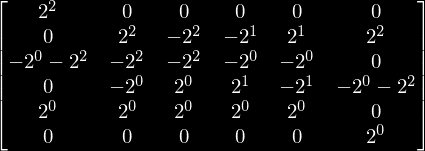

In [25]:
log2_matrix(log2_lst(c_mtx))

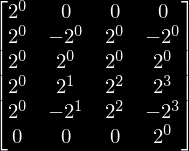

In [27]:
log2_matrix(log2_lst(a_mtx))

In [18]:
bg_mtx = g2bg(cq, b_mtx, g_values)

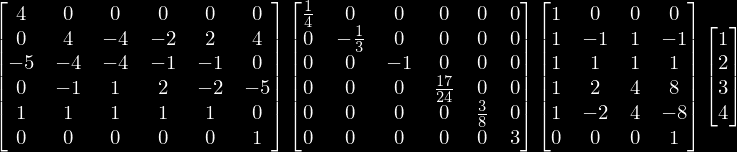

In [19]:
s = sy.MatMul(c_mtx, bg_mtx, a_mtx, sy.Matrix(d_values))
s

Comparing numerical outputs from direct and winograd method

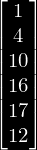

In [20]:
sy.Matrix(np.convolve(d_values, g_values))

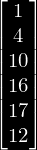

In [21]:
sy.MatMul(c_mtx, bg_mtx, a_mtx, sy.Matrix(d_values), evaluate=True)